# Amazon-Style E-Commerce Sales Analytics

## 04 — Product & Category Performance Analysis

### Objective

The objective of this notebook is to analyze product and category performance using sales value, units sold, order volume, pricing, discounts, and revenue contribution.

The analysis aims to identify high-performing and underperforming products and categories, understand the relationship between sales volume and sales value, and identify potential opportunities for product and category-level business decisions.

### Important Limitation

The dataset does not contain product cost or profit information. Therefore, profitability and profit margin cannot be calculated reliably.

This notebook focuses on:

- Sales value
- Units sold
- Order volume
- Average Order Value
- Average selling price
- Discount levels
- Revenue contribution
- Product and category rankings

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (100000, 25)


## 1. Product & Category Overview

The dataset is first examined at the product, category, and brand levels to understand the available product hierarchy.

In [6]:
product_count = df["ProductID"].nunique()
product_name_count = df["ProductName"].nunique()
category_count = df["Category"].nunique()
brand_count = df["Brand"].nunique()

print(f"Unique Products      : {product_count:,}")
print(f"Unique Product Names : {product_name_count:,}")
print(f"Categories           : {category_count:,}")
print(f"Brands               : {brand_count:,}")

Unique Products      : 50
Unique Product Names : 50
Categories           : 6
Brands               : 10


In [7]:
product_mapping = (
    df[
        [
            "ProductID",
            "ProductName",
            "Category",
            "Brand"
        ]
    ]
    .drop_duplicates()
    .sort_values(["Category", "ProductName"])
)

product_mapping.head(20)

,ProductID,ProductName,Category,Brand
591,P00008,4K Monitor,Books,ReadMore
677,P00008,4K Monitor,Books,Zenith
792,P00008,4K Monitor,Books,KiddoFun
923,P00008,4K Monitor,Books,FitLife
1834,P00008,4K Monitor,Books,Apex
3357,P00008,4K Monitor,Books,NexPro
5985,P00008,4K Monitor,Books,HomeEase
7434,P00008,4K Monitor,Books,UrbanStyle
7885,P00008,4K Monitor,Books,BrightLux
7928,P00008,4K Monitor,Books,CoreTech


In [8]:
product_category_check = (
    df.groupby("ProductID")["Category"]
      .nunique()
      .sort_values(ascending=False)
)

print(
    "Products associated with multiple categories:",
    (product_category_check > 1).sum()
)

Products associated with multiple categories: 50


In [9]:
product_brand_check = (
    df.groupby("ProductID")["Brand"]
      .nunique()
      .sort_values(ascending=False)
)

print(
    "Products associated with multiple brands:",
    (product_brand_check > 1).sum()
)

Products associated with multiple brands: 50


## 2. Category Revenue Performance

Category-level revenue performance is analyzed to identify the categories contributing the largest share of total sales value.

In [10]:
category_performance = (
    df.groupby("Category")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .reset_index()
)

category_performance["Revenue_Share_%"] = (
    category_performance["Revenue"] /
    category_performance["Revenue"].sum() * 100
)

category_performance = (
    category_performance
    .sort_values("Revenue", ascending=False)
)

category_performance

,Category,Revenue,Orders,Units,Revenue_Share_%
2,Electronics,15584217.18,16853,50696,16.971530
4,Sports & Outdoors,15345571.88,16804,50543,16.711640
0,Books,15261837.01,16752,49981,16.620451
1,Clothing,15253397.50,16439,49523,16.611260
5,Toys & Games,15216684.99,16542,49773,16.571280
3,Home & Kitchen,15163939.36,16610,49624,16.513839


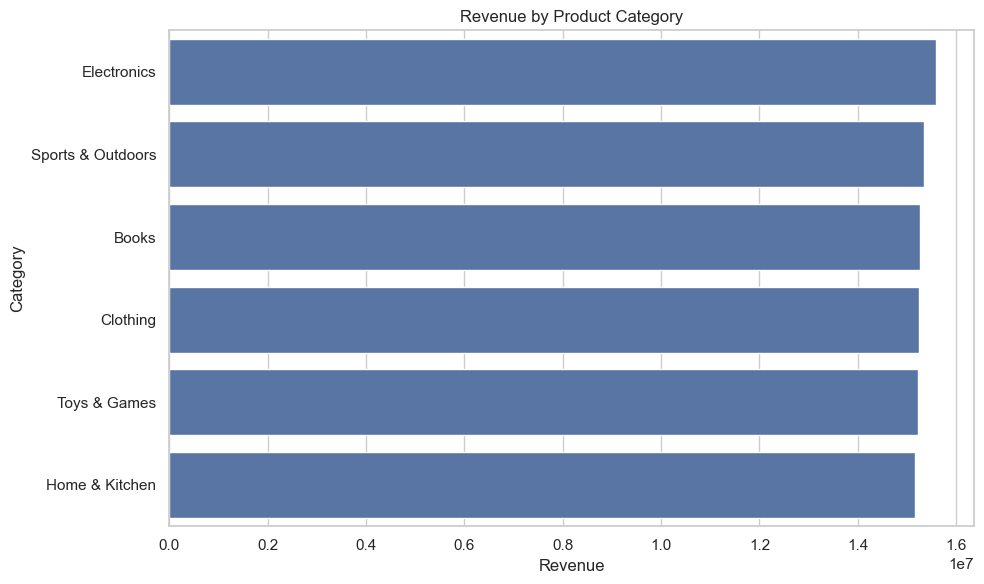

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_performance,
    x="Revenue",
    y="Category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 3. Category Sales Volume

Units sold and order volume are analyzed alongside revenue to distinguish high-value categories from high-volume categories.

In [12]:
category_volume = (
    df.groupby("Category")
      .agg(
          Units_Sold=("Quantity", "sum"),
          Orders=("OrderID", "nunique")
      )
      .reset_index()
      .sort_values("Units_Sold", ascending=False)
)

category_volume

,Category,Units_Sold,Orders
2,Electronics,50696,16853
4,Sports & Outdoors,50543,16804
0,Books,49981,16752
5,Toys & Games,49773,16542
3,Home & Kitchen,49624,16610
1,Clothing,49523,16439


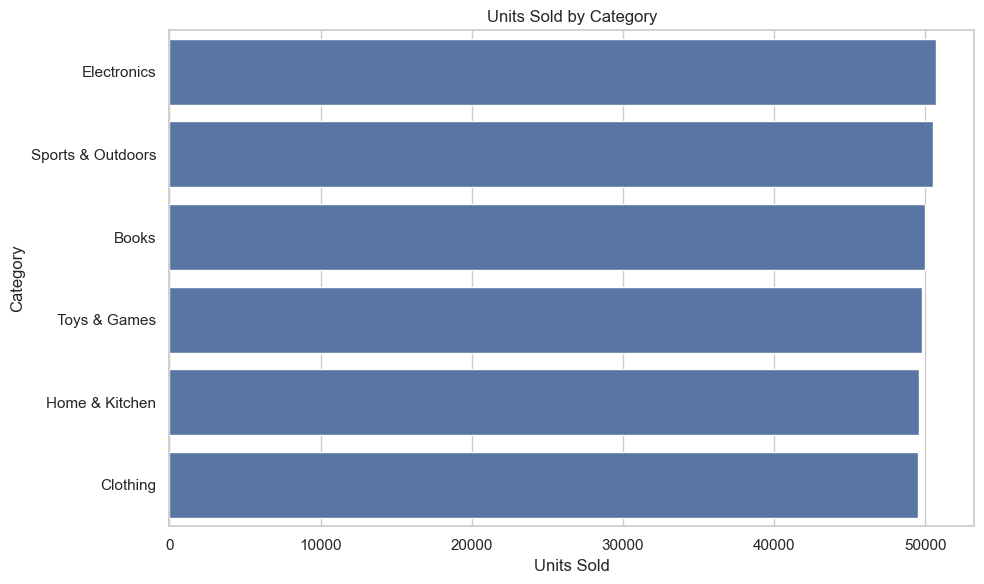

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_volume,
    x="Units_Sold",
    y="Category"
)

plt.title("Units Sold by Category")
plt.xlabel("Units Sold")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

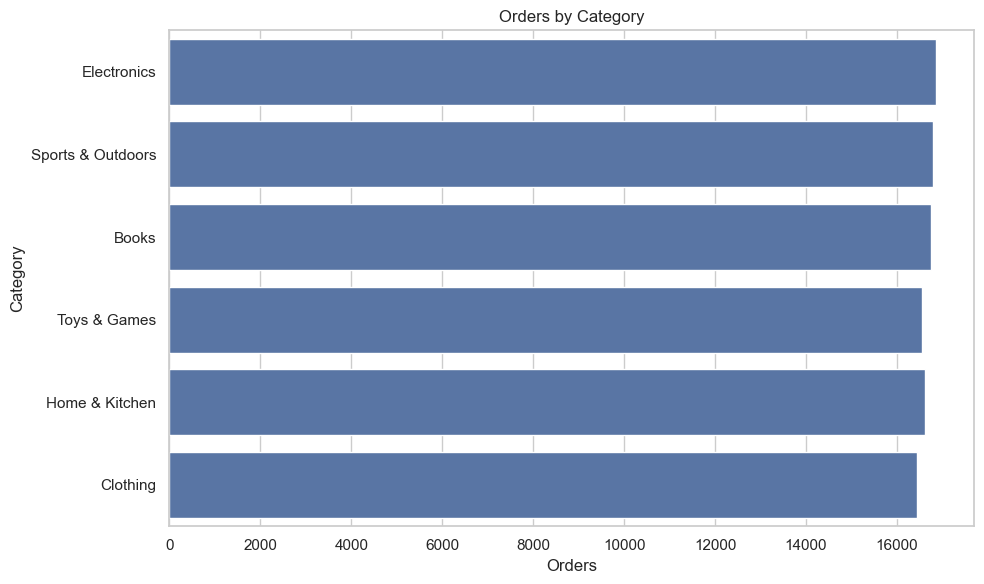

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_volume,
    x="Orders",
    y="Category"
)

plt.title("Orders by Category")
plt.xlabel("Orders")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 4. Category Average Order Value and Pricing

Average Order Value and average selling price are analyzed to understand whether categories generate sales through higher transaction values or higher sales volume.

In [15]:
category_pricing = (
    df.groupby("Category")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Unit_Price=("UnitPrice", "mean")
      )
      .reset_index()
)

category_pricing["Revenue_per_Unit"] = (
    category_pricing["Revenue"] /
    category_pricing["Units"]
)

category_pricing.sort_values(
    "Revenue",
    ascending=False
)

,Category,Revenue,Orders,Units,Average_Order_Value,Average_Unit_Price,Revenue_per_Unit
2,Electronics,15584217.18,16853,50696,924.714720,302.926827,307.405262
4,Sports & Outdoors,15345571.88,16804,50543,913.209467,301.757574,303.614188
0,Books,15261837.01,16752,49981,911.045667,302.023176,305.352774
1,Clothing,15253397.50,16439,49523,927.878673,305.196414,308.006330
5,Toys & Games,15216684.99,16542,49773,919.881815,302.810143,305.721676
3,Home & Kitchen,15163939.36,16610,49624,912.940359,302.764196,305.576724


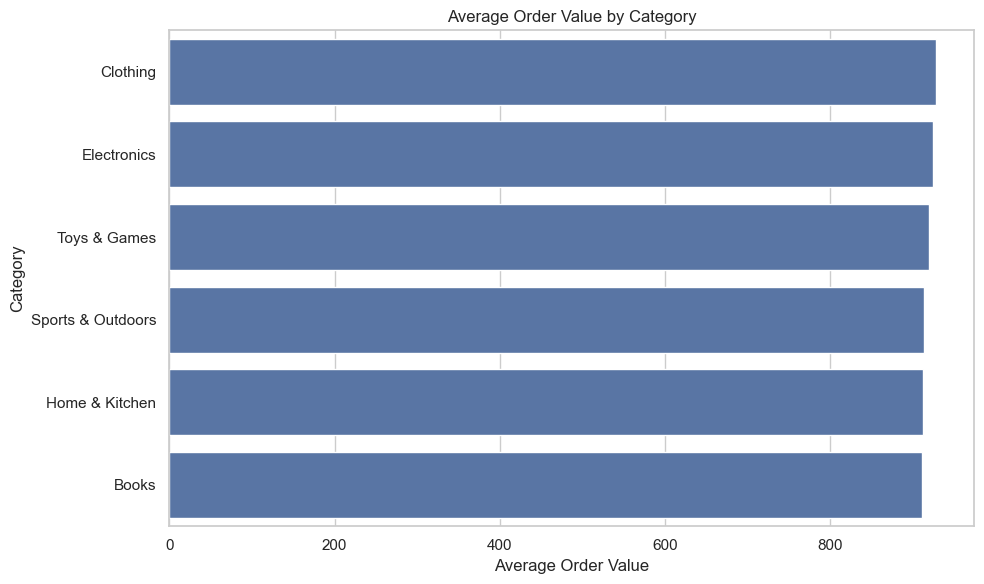

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_pricing.sort_values(
        "Average_Order_Value",
        ascending=False
    ),
    x="Average_Order_Value",
    y="Category"
)

plt.title("Average Order Value by Category")
plt.xlabel("Average Order Value")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

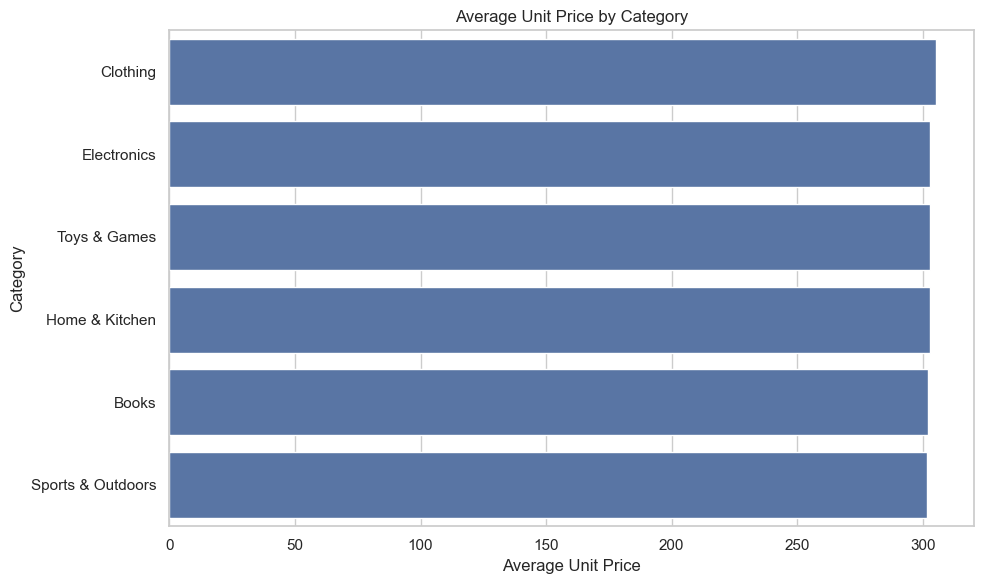

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_pricing.sort_values(
        "Average_Unit_Price",
        ascending=False
    ),
    x="Average_Unit_Price",
    y="Category"
)

plt.title("Average Unit Price by Category")
plt.xlabel("Average Unit Price")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 5. Category Discount Analysis

Discount levels are analyzed to determine which categories receive higher average discounts and whether discounting is associated with sales volume.

In [18]:
category_discount = (
    df.groupby("Category")
      .agg(
          Average_Discount=("Discount", "mean"),
          Median_Discount=("Discount", "median"),
          Revenue=("TotalAmount", "sum"),
          Units=("Quantity", "sum")
      )
      .reset_index()
      .sort_values("Average_Discount", ascending=False)
)

category_discount

,Category,Average_Discount,Median_Discount,Revenue,Units
3,Home & Kitchen,0.075084,0.05,15163939.36,49624
2,Electronics,0.074340,0.05,15584217.18,50696
5,Toys & Games,0.074066,0.05,15216684.99,49773
4,Sports & Outdoors,0.074000,0.05,15345571.88,50543
1,Clothing,0.073970,0.05,15253397.50,49523
0,Books,0.073896,0.05,15261837.01,49981


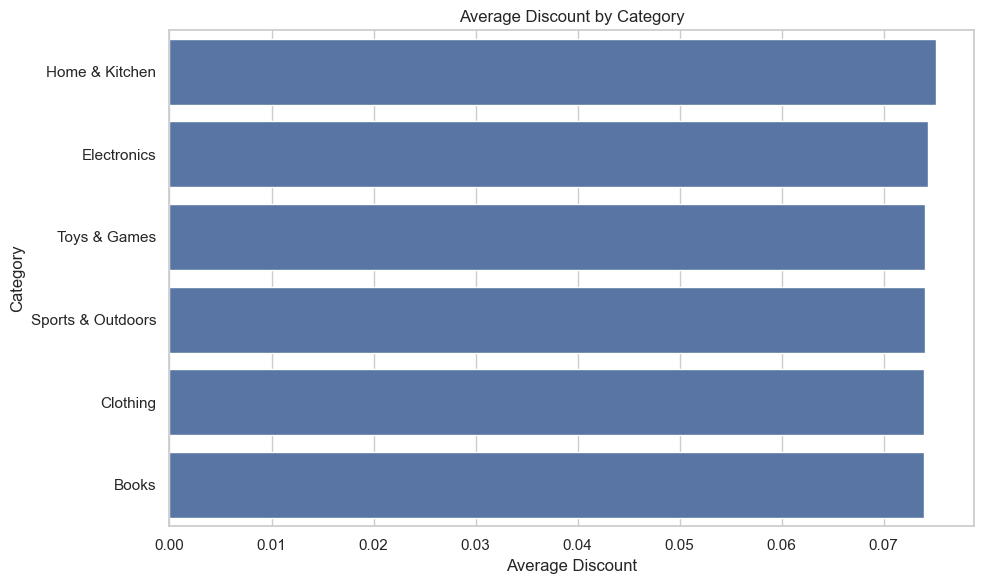

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_discount,
    x="Average_Discount",
    y="Category"
)

plt.title("Average Discount by Category")
plt.xlabel("Average Discount")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

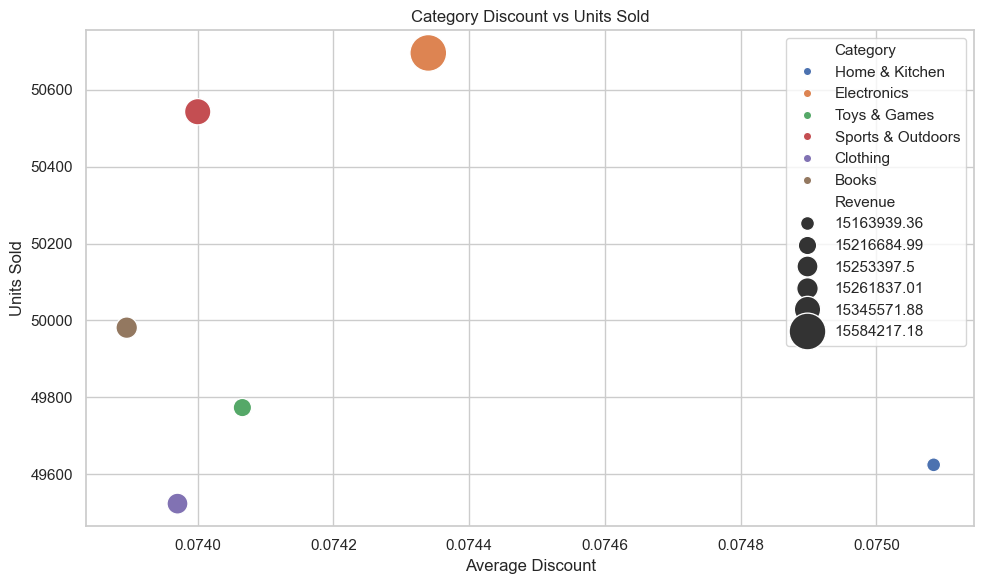

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_discount,
    x="Average_Discount",
    y="Units",
    size="Revenue",
    hue="Category",
    sizes=(100, 700)
)

plt.title("Category Discount vs Units Sold")
plt.xlabel("Average Discount")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

## 6. Category Revenue vs Sales Volume

Revenue and unit volume are compared to identify categories that are:

- High revenue / high volume
- High revenue / low volume
- Low revenue / high volume
- Low revenue / low volume

In [22]:
category_matrix = (
    df.groupby("Category")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Units=("Quantity", "sum"),
          Orders=("OrderID", "nunique")
      )
      .reset_index()
)

category_matrix

,Category,Revenue,Units,Orders
0,Books,15261837.01,49981,16752
1,Clothing,15253397.50,49523,16439
2,Electronics,15584217.18,50696,16853
3,Home & Kitchen,15163939.36,49624,16610
4,Sports & Outdoors,15345571.88,50543,16804
5,Toys & Games,15216684.99,49773,16542


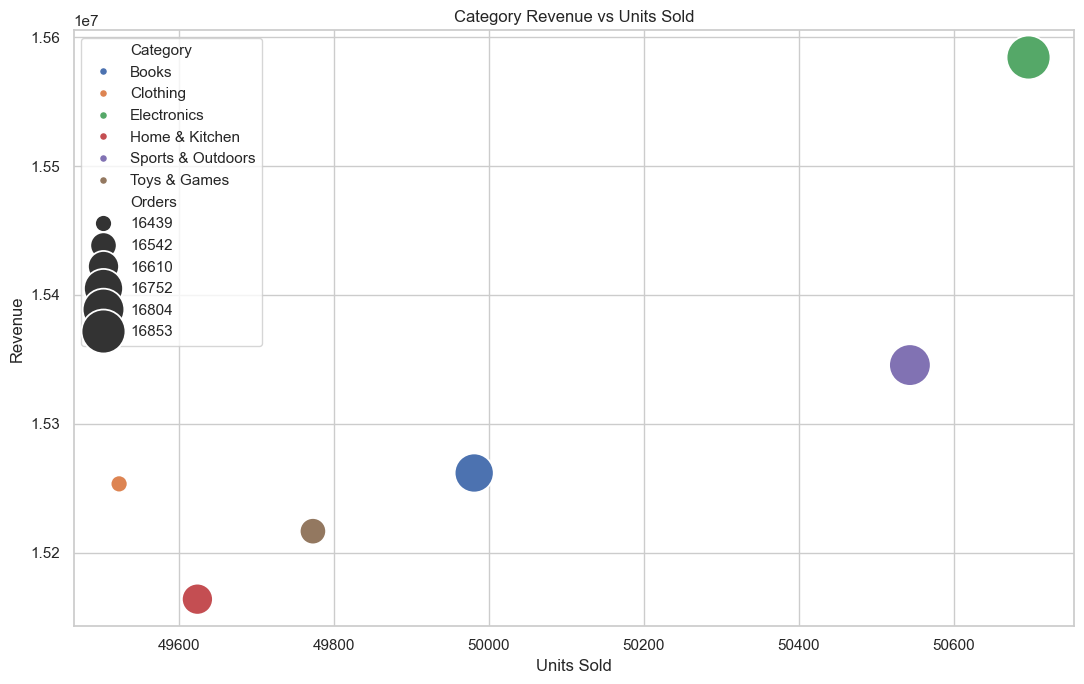

In [23]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=category_matrix,
    x="Units",
    y="Revenue",
    size="Orders",
    hue="Category",
    sizes=(150, 1000)
)

plt.title("Category Revenue vs Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

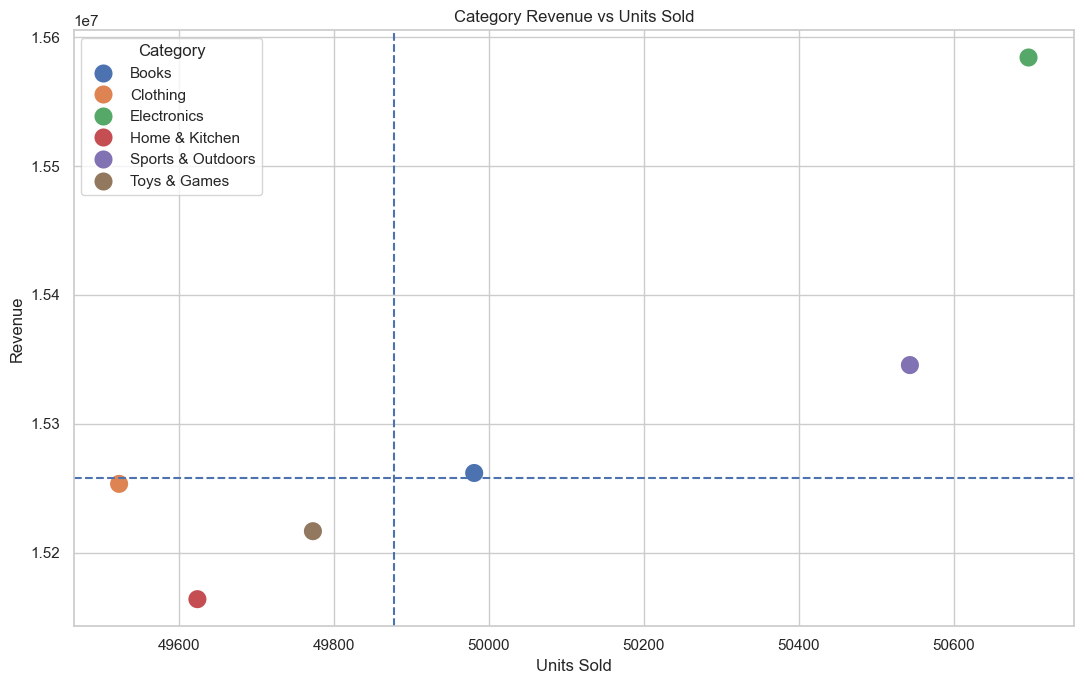

In [24]:
median_units = category_matrix["Units"].median()
median_revenue = category_matrix["Revenue"].median()

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=category_matrix,
    x="Units",
    y="Revenue",
    hue="Category",
    s=200
)

plt.axvline(
    median_units,
    linestyle="--"
)

plt.axhline(
    median_revenue,
    linestyle="--"
)

plt.title("Category Revenue vs Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## 7. Brand Performance

Brand-level analysis identifies the brands contributing the highest sales value and sales volume.

In [25]:
brand_performance = (
    df.groupby("Brand")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          AOV=("TotalAmount", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

brand_performance["Revenue_Share_%"] = (
    brand_performance["Revenue"] /
    brand_performance["Revenue"].sum() * 100
)

brand_performance = brand_performance.sort_values(
    "Revenue",
    ascending=False
)

brand_performance

,Brand,Revenue,Orders,Units,AOV,Average_Discount,Revenue_Share_%
2,CoreTech,9343720.59,10127,30430,922.654349,0.073413,10.175502
5,KiddoFun,9324749.55,10077,30168,925.349762,0.074253,10.154842
7,ReadMore,9278406.63,10204,30421,909.291124,0.073182,10.104374
8,UrbanStyle,9249027.45,9854,30104,938.606398,0.075223,10.072379
9,Zenith,9239960.39,9990,30058,924.920960,0.073158,10.062505
0,Apex,9147604.72,9937,29955,920.560000,0.074479,9.961928
6,NexPro,9078824.97,9962,29791,911.345610,0.074498,9.887025
3,FitLife,9061444.68,10147,30121,893.017116,0.075791,9.868098
1,BrightLux,9056816.11,9907,29616,914.183518,0.074533,9.863057
4,HomeEase,9045092.83,9795,29476,923.439799,0.073747,9.850290


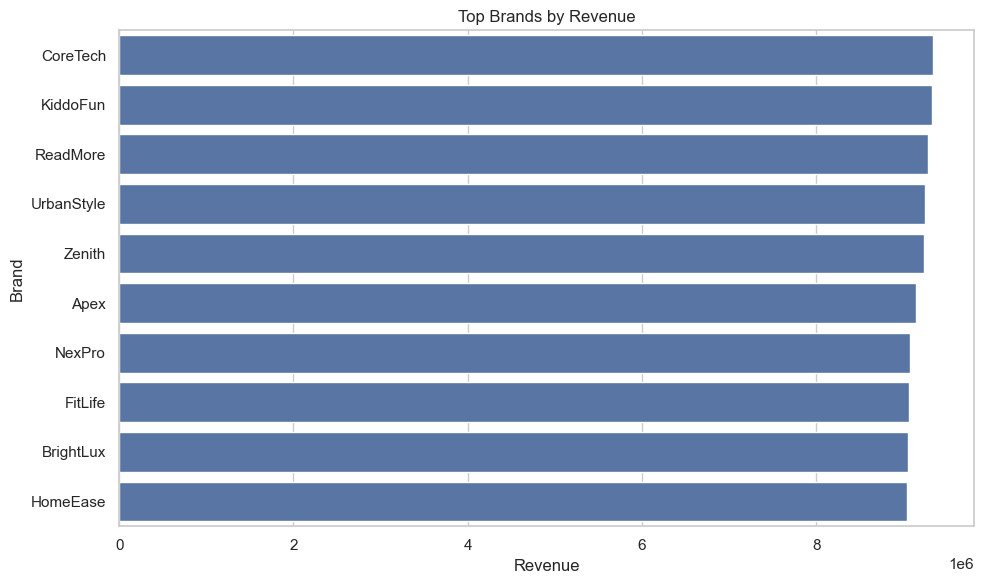

In [26]:
top_brands = brand_performance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_brands,
    x="Revenue",
    y="Brand"
)

plt.title("Top Brands by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

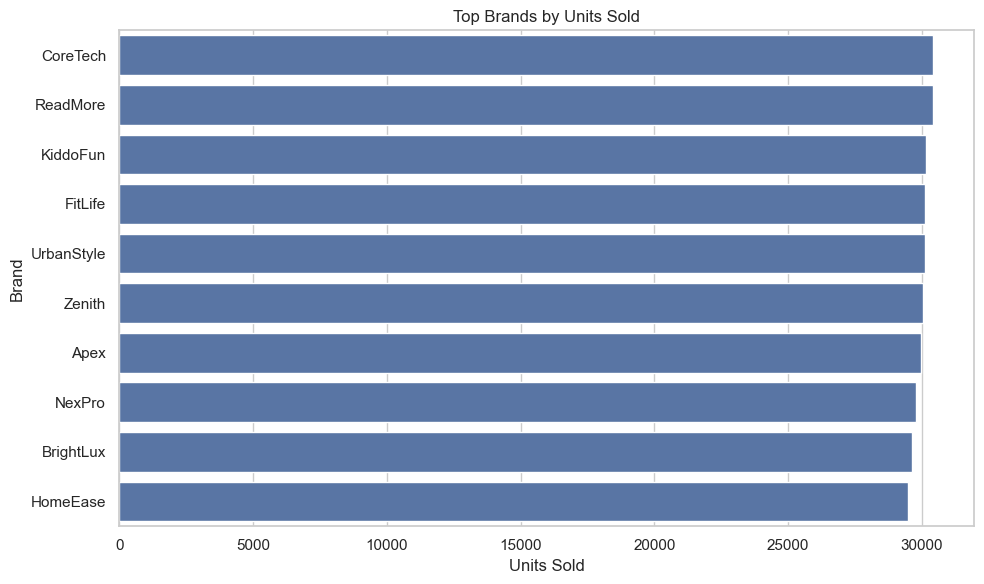

In [27]:
top_brands_units = (
    brand_performance
    .sort_values("Units", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_brands_units,
    x="Units",
    y="Brand"
)

plt.title("Top Brands by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

## 8. Product Revenue Ranking

Individual products are ranked according to their contribution to total sales value.

In [28]:
product_performance = (
    df.groupby(
        ["ProductID", "ProductName", "Category", "Brand"]
    )
    .agg(
        Revenue=("TotalAmount", "sum"),
        Orders=("OrderID", "nunique"),
        Units=("Quantity", "sum"),
        Average_Unit_Price=("UnitPrice", "mean"),
        Average_Discount=("Discount", "mean"),
        AOV=("TotalAmount", "mean")
    )
    .reset_index()
)

product_performance["Revenue_Share_%"] = (
    product_performance["Revenue"] /
    product_performance["Revenue"].sum() * 100
)

product_performance = product_performance.sort_values(
    "Revenue",
    ascending=False
)

product_performance.head(20)

,ProductID,ProductName,Category,Brand,Revenue,Orders,Units,Average_Unit_Price,Average_Discount,AOV,Revenue_Share_%
1995,P00034,Desk Organizer,Clothing,KiddoFun,58059.53,58,166,348.706034,0.095690,1001.026379,0.063228
1660,P00028,Jeans,Sports & Outdoors,Apex,56329.85,50,156,361.225800,0.063000,1126.597000,0.061344
2794,P00047,Memory Card 128GB,Home & Kitchen,HomeEase,55874.05,53,162,341.489623,0.096226,1054.227358,0.060848
1325,P00023,Cookware Set,Books,KiddoFun,53889.96,43,147,379.811860,0.060465,1253.254884,0.058687
2549,P00043,HDMI Cable 2m,Electronics,Zenith,53200.52,48,154,334.984375,0.078125,1108.344167,0.057936
1120,P00019,LED Desk Lamp,Sports & Outdoors,Apex,52494.29,52,167,317.057308,0.082692,1009.505577,0.057167
467,P00008,4K Monitor,Sports & Outdoors,ReadMore,52452.39,59,181,279.351017,0.074576,889.023559,0.057122
229,P00004,USB-C Charger,Sports & Outdoors,Zenith,52155.04,47,141,358.602340,0.059574,1109.681702,0.056798
394,P00007,Mechanical Keyboard,Home & Kitchen,HomeEase,51373.57,43,144,371.082558,0.070930,1194.734186,0.055947
1132,P00019,LED Desk Lamp,Toys & Games,CoreTech,51046.67,43,155,308.907674,0.074419,1187.131860,0.055591


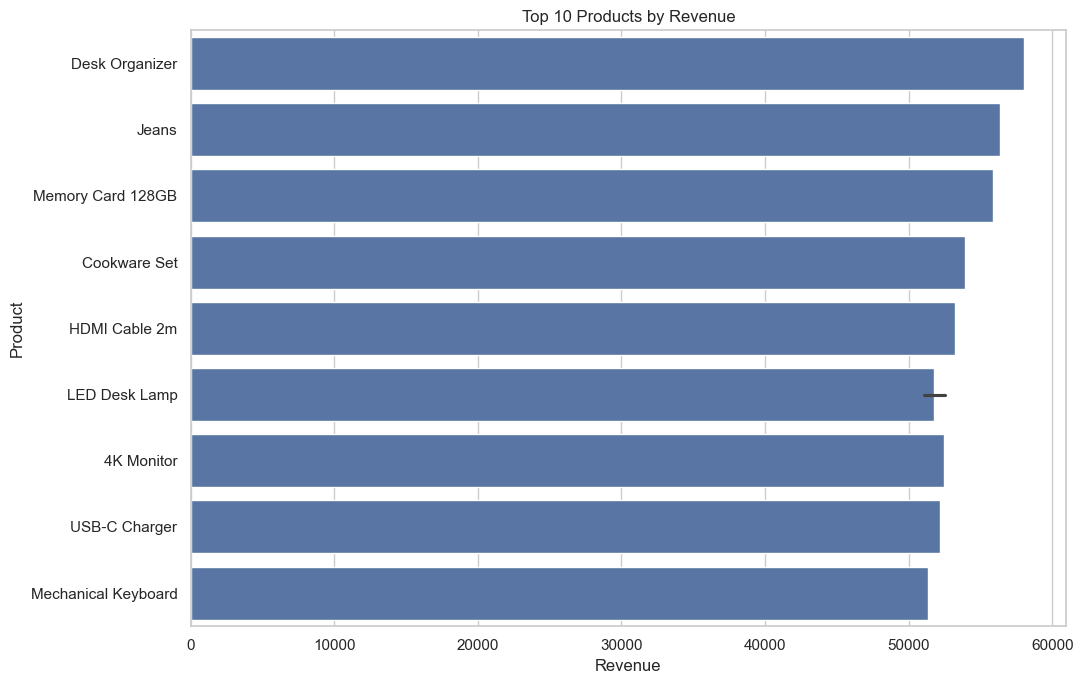

In [29]:
top_10_products = product_performance.head(10)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_10_products,
    x="Revenue",
    y="ProductName"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## 9. Product Sales Volume

Products are ranked according to the number of units sold.

In [30]:
top_volume_products = (
    product_performance
    .sort_values("Units", ascending=False)
    .head(10)
)

top_volume_products

,ProductID,ProductName,Category,Brand,Revenue,Orders,Units,Average_Unit_Price,Average_Discount,AOV,Revenue_Share_%
467,P00008,4K Monitor,Sports & Outdoors,ReadMore,52452.39,59,181,279.351017,0.074576,889.023559,0.057122
1120,P00019,LED Desk Lamp,Sports & Outdoors,Apex,52494.29,52,167,317.057308,0.082692,1009.505577,0.057167
1995,P00034,Desk Organizer,Clothing,KiddoFun,58059.53,58,166,348.706034,0.095690,1001.026379,0.063228
1157,P00020,Office Chair,Clothing,ReadMore,50377.28,53,164,316.598302,0.075472,950.514717,0.054862
1249,P00021,Backpack,Sports & Outdoors,Zenith,45992.18,48,164,308.032917,0.071875,958.170417,0.050086
27,P00001,Wireless Earbuds,Electronics,ReadMore,48818.67,50,163,296.404400,0.067000,976.373400,0.053165
2794,P00047,Memory Card 128GB,Home & Kitchen,HomeEase,55874.05,53,162,341.489623,0.096226,1054.227358,0.060848
15,P00001,Wireless Earbuds,Clothing,KiddoFun,48199.60,48,160,292.068750,0.069792,1004.158333,0.052490
1660,P00028,Jeans,Sports & Outdoors,Apex,56329.85,50,156,361.225800,0.063000,1126.597000,0.061344
2396,P00040,Microphone,Toys & Games,NexPro,41576.85,51,156,279.732157,0.080392,815.232353,0.045278


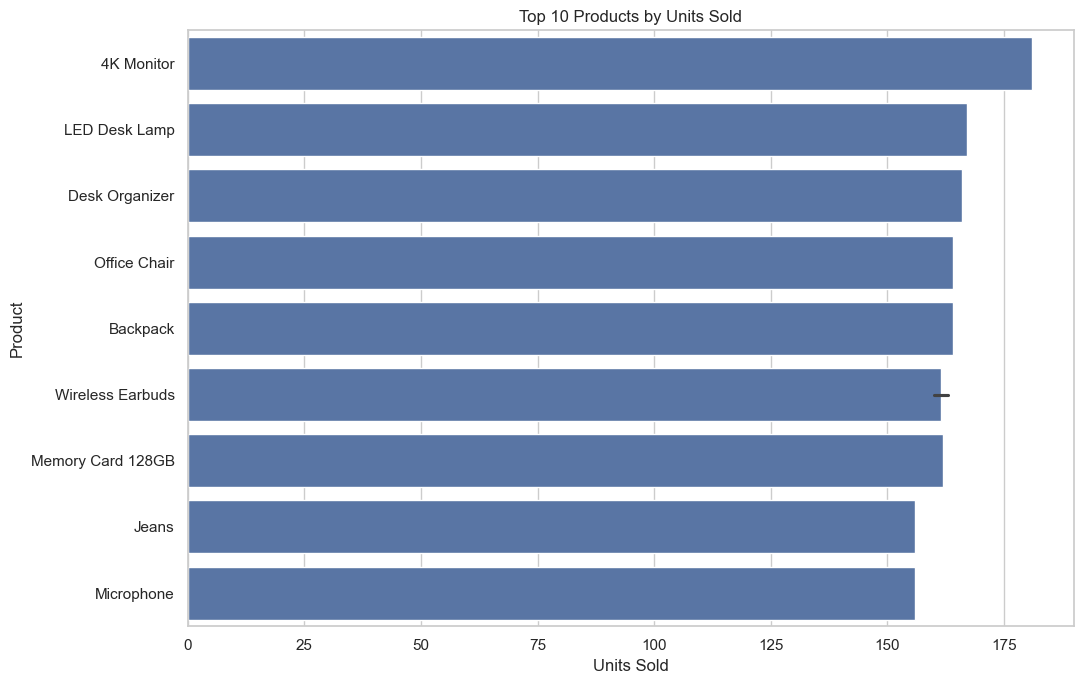

In [31]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_volume_products,
    x="Units",
    y="ProductName"
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## 10. Product Pricing Analysis

Product-level pricing is analyzed to identify products with relatively high and low average selling prices.

In [32]:
highest_price_products = (
    product_performance
    .sort_values(
        "Average_Unit_Price",
        ascending=False
    )
    .head(10)
)

highest_price_products[
    [
        "ProductName",
        "Category",
        "Brand",
        "Average_Unit_Price",
        "Units",
        "Revenue"
    ]
]

,ProductName,Category,Brand,Average_Unit_Price,Units,Revenue
2348,Microphone,Books,UrbanStyle,401.982500,83,34372.18
892,Instant Pot,Toys & Games,CoreTech,397.380938,87,32891.86
569,Smartwatch,Electronics,Zenith,396.584000,87,34539.14
2337,Graphic Tablet,Toys & Games,ReadMore,392.667586,94,35196.20
854,Instant Pot,Clothing,HomeEase,392.557083,62,23203.17
2658,Phone Tripod,Clothing,UrbanStyle,392.211613,100,38815.31
2191,Router,Home & Kitchen,BrightLux,390.597500,97,35219.77
1914,Board Game,Toys & Games,HomeEase,389.384687,108,41893.11
324,Gaming Mouse,Electronics,HomeEase,389.052069,85,33559.54
1109,LED Desk Lamp,Electronics,Zenith,387.942000,102,38469.69


In [33]:
lowest_price_products = (
    product_performance
    .sort_values(
        "Average_Unit_Price",
        ascending=True
    )
    .head(10)
)

lowest_price_products[
    [
        "ProductName",
        "Category",
        "Brand",
        "Average_Unit_Price",
        "Units",
        "Revenue"
    ]
]

,ProductName,Category,Brand,Average_Unit_Price,Units,Revenue
2298,Graphic Tablet,Clothing,UrbanStyle,206.757941,103,20765.66
1615,Winter Jacket,Toys & Games,KiddoFun,210.461304,75,16108.99
770,Action Camera,Toys & Games,Apex,213.683600,73,17249.08
1232,Backpack,Home & Kitchen,CoreTech,216.082258,84,16320.13
1873,Board Game,Clothing,FitLife,219.722143,127,29482.48
1220,Backpack,Electronics,Apex,219.864062,92,22058.50
1058,Vacuum Cleaner,Home & Kitchen,UrbanStyle,220.305385,87,20491.42
2345,Microphone,Books,KiddoFun,221.822703,105,19714.78
2858,Wireless Charger,Home & Kitchen,UrbanStyle,221.987105,112,23114.12
2667,Phone Tripod,Electronics,ReadMore,222.070571,102,21867.10


## 11. Product Discount Analysis

Discount levels are examined at the product level to identify products receiving relatively high discounts and to compare discounting with sales performance.

In [34]:
highest_discount_products = (
    product_performance
    .sort_values(
        "Average_Discount",
        ascending=False
    )
    .head(15)
)

highest_discount_products[
    [
        "ProductName",
        "Category",
        "Brand",
        "Average_Discount",
        "Units",
        "Revenue"
    ]
]

,ProductName,Category,Brand,Average_Discount,Units,Revenue
2478,Projector Mini,Clothing,UrbanStyle,0.132609,70,22736.04
2921,Children's Book,Sports & Outdoors,BrightLux,0.130645,90,22716.00
2769,Memory Card 128GB,Books,Zenith,0.130556,49,13935.50
1558,Sunglasses,Toys & Games,UrbanStyle,0.126087,64,17338.62
2156,Smart Light Bulb,Toys & Games,NexPro,0.125000,68,17591.53
2948,Novel Bestseller,Books,UrbanStyle,0.125000,70,19538.54
1348,Cookware Set,Electronics,UrbanStyle,0.123214,83,25089.11
2746,Car Charger,Sports & Outdoors,NexPro,0.122414,94,28847.89
1172,Office Chair,Home & Kitchen,CoreTech,0.121053,105,29190.66
1613,Winter Jacket,Toys & Games,FitLife,0.118519,81,23708.92


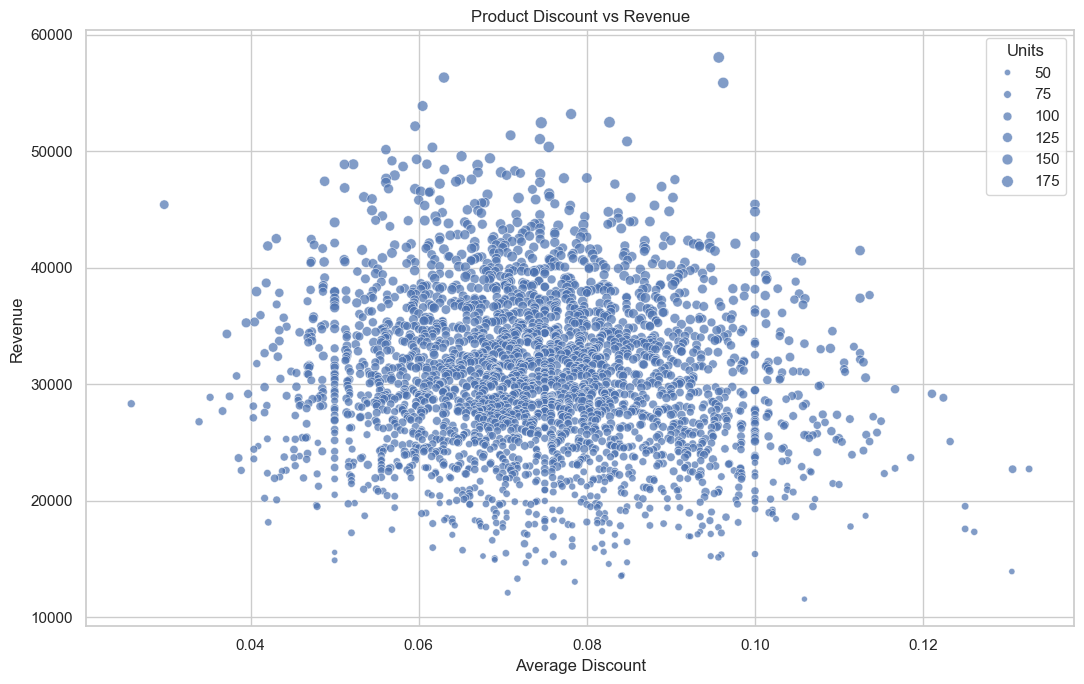

In [35]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=product_performance,
    x="Average_Discount",
    y="Revenue",
    size="Units",
    alpha=0.7
)

plt.title("Product Discount vs Revenue")
plt.xlabel("Average Discount")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## 12. High-Volume vs High-Value Products

Products are classified according to whether they perform above or below the median in revenue and unit volume.

This creates four analytical groups:

- High Revenue / High Volume
- High Revenue / Low Volume
- Low Revenue / High Volume
- Low Revenue / Low Volume

In [36]:
median_product_revenue = (
    product_performance["Revenue"].median()
)

median_product_units = (
    product_performance["Units"].median()
)

print(
    f"Median Product Revenue: "
    f"${median_product_revenue:,.2f}"
)

print(
    f"Median Product Units: "
    f"{median_product_units:,.0f}"
)

Median Product Revenue: $30,293.17
Median Product Units: 100


In [37]:
def classify_product(row):
    if (
        row["Revenue"] >= median_product_revenue
        and row["Units"] >= median_product_units
    ):
        return "High Revenue / High Volume"

    elif (
        row["Revenue"] >= median_product_revenue
        and row["Units"] < median_product_units
    ):
        return "High Revenue / Low Volume"

    elif (
        row["Revenue"] < median_product_revenue
        and row["Units"] >= median_product_units
    ):
        return "Low Revenue / High Volume"

    else:
        return "Low Revenue / Low Volume"


product_performance["Performance_Segment"] = (
    product_performance.apply(
        classify_product,
        axis=1
    )
)

In [38]:
product_segment_summary = (
    product_performance
    .groupby("Performance_Segment")
    .agg(
        Products=("ProductID", "count"),
        Revenue=("Revenue", "sum"),
        Units=("Units", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

product_segment_summary

,Products,Revenue,Units
Performance_Segment,,,
High Revenue / High Volume,1246,45644616.62,146133
Low Revenue / Low Volume,1242,30646594.27,102782
High Revenue / Low Volume,254,8266812.88,23896
Low Revenue / High Volume,258,7267624.15,27329


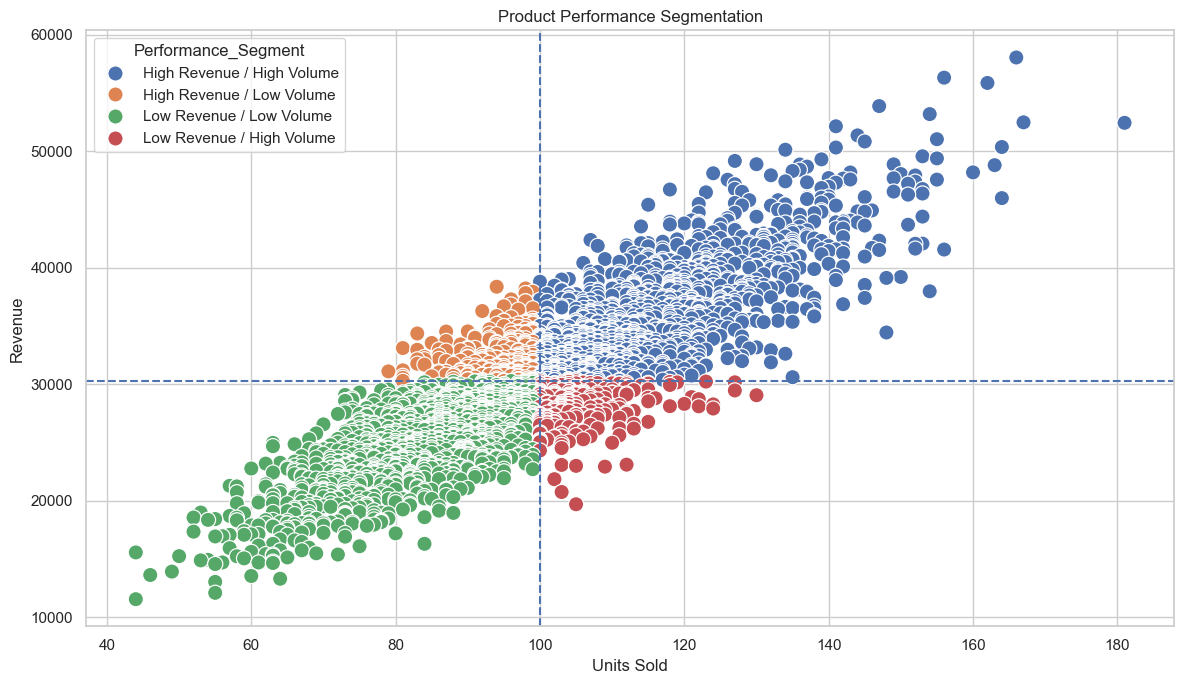

In [39]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=product_performance,
    x="Units",
    y="Revenue",
    hue="Performance_Segment",
    s=120
)

plt.axvline(
    median_product_units,
    linestyle="--"
)

plt.axhline(
    median_product_revenue,
    linestyle="--"
)

plt.title("Product Performance Segmentation")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## 13. Product Revenue Concentration

Product revenue concentration is analyzed to determine how much of total sales value is generated by the highest-ranked products.

In [40]:
product_concentration = (
    product_performance
    [
        [
            "ProductID",
            "ProductName",
            "Revenue"
        ]
    ]
    .sort_values(
        "Revenue",
        ascending=False
    )
    .copy()
)

product_concentration["Cumulative_Revenue"] = (
    product_concentration["Revenue"].cumsum()
)

product_concentration["Cumulative_Revenue_Share_%"] = (
    product_concentration["Cumulative_Revenue"] /
    product_concentration["Revenue"].sum() * 100
)

product_concentration["Product_Rank"] = (
    range(1, len(product_concentration) + 1)
)

product_concentration

,ProductID,ProductName,Revenue,Cumulative_Revenue,Cumulative_Revenue_Share_%,Product_Rank
1995,P00034,Desk Organizer,58059.53,58059.53,0.063228,1
1660,P00028,Jeans,56329.85,114389.38,0.124572,2
2794,P00047,Memory Card 128GB,55874.05,170263.43,0.185420,3
1325,P00023,Cookware Set,53889.96,224153.39,0.244108,4
2549,P00043,HDMI Cable 2m,53200.52,277353.91,0.302044,5
...,...,...,...,...,...,...
1686,P00029,T-Shirt,13558.80,91775589.54,99.945485,2996
447,P00008,4K Monitor,13322.53,91788912.07,99.959994,2997
1198,P00020,Office Chair,13053.29,91801965.36,99.974209,2998
1230,P00021,Backpack,12113.18,91814078.54,99.987401,2999


In [41]:
top_10_product_revenue_share = (
    product_concentration
    .head(10)["Revenue"]
    .sum()
    /
    product_concentration["Revenue"].sum()
    * 100
)

print(
    f"Top 10 products contribute "
    f"{top_10_product_revenue_share:.2f}% "
    f"of total product revenue."
)

Top 10 products contribute 0.58% of total product revenue.


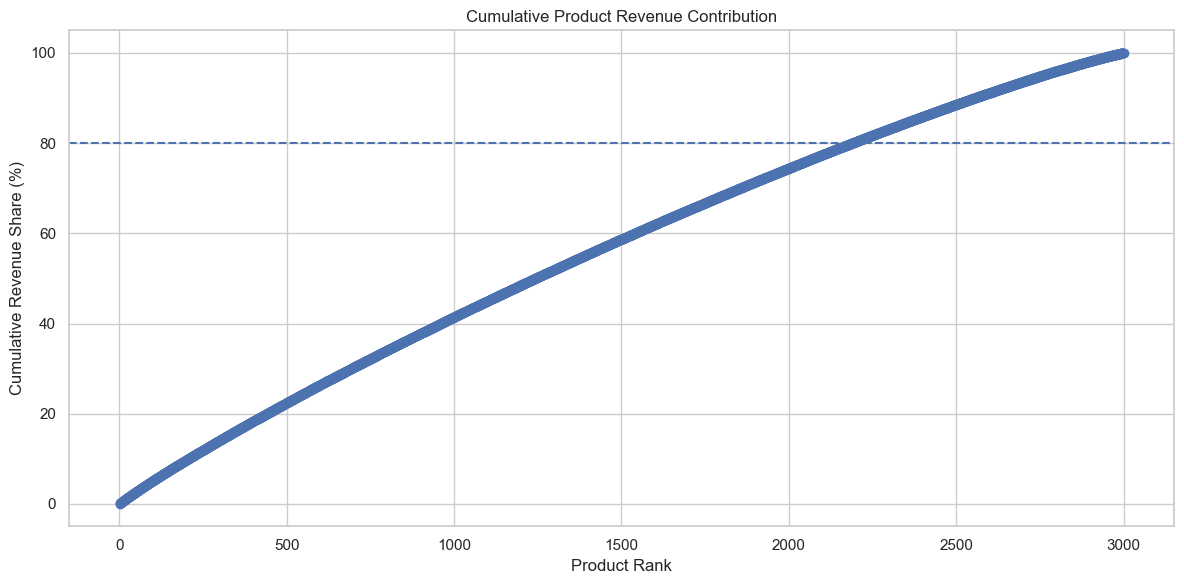

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    product_concentration["Product_Rank"],
    product_concentration[
        "Cumulative_Revenue_Share_%"
    ],
    marker="o"
)

plt.axhline(
    80,
    linestyle="--"
)

plt.title("Cumulative Product Revenue Contribution")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative Revenue Share (%)")

plt.tight_layout()
plt.show()

## 14. Category and Brand Performance

A category-brand matrix is used to identify combinations that contribute strongly to sales.

In [43]:
category_brand_revenue = pd.pivot_table(
    df,
    values="TotalAmount",
    index="Category",
    columns="Brand",
    aggfunc="sum",
    fill_value=0
)

category_brand_revenue

Brand,Apex,BrightLux,CoreTech,FitLife,HomeEase,KiddoFun,NexPro,ReadMore,UrbanStyle,Zenith
Category,,,,,,,,,,
Books,1514263.54,1499420.87,1629735.16,1576480.34,1476865.85,1537266.35,1491574.01,1487081.92,1556180.08,1492968.89
Clothing,1532797.49,1499106.72,1498071.53,1524052.12,1514823.68,1549641.84,1506443.67,1540555.20,1562258.95,1525646.30
Electronics,1542954.01,1540792.25,1554056.04,1511570.19,1549664.82,1595636.15,1571702.22,1546408.51,1602475.96,1568957.03
Home & Kitchen,1413580.44,1555239.61,1486798.76,1461579.14,1558517.28,1540842.69,1484583.19,1578177.57,1499315.07,1585305.61
Sports & Outdoors,1622641.60,1481872.24,1544616.12,1541289.80,1459499.61,1533294.61,1508062.43,1582006.48,1550586.05,1521702.94
Toys & Games,1521367.64,1480384.42,1630442.98,1446473.09,1485721.59,1568067.91,1516459.45,1544176.95,1478211.34,1545379.62


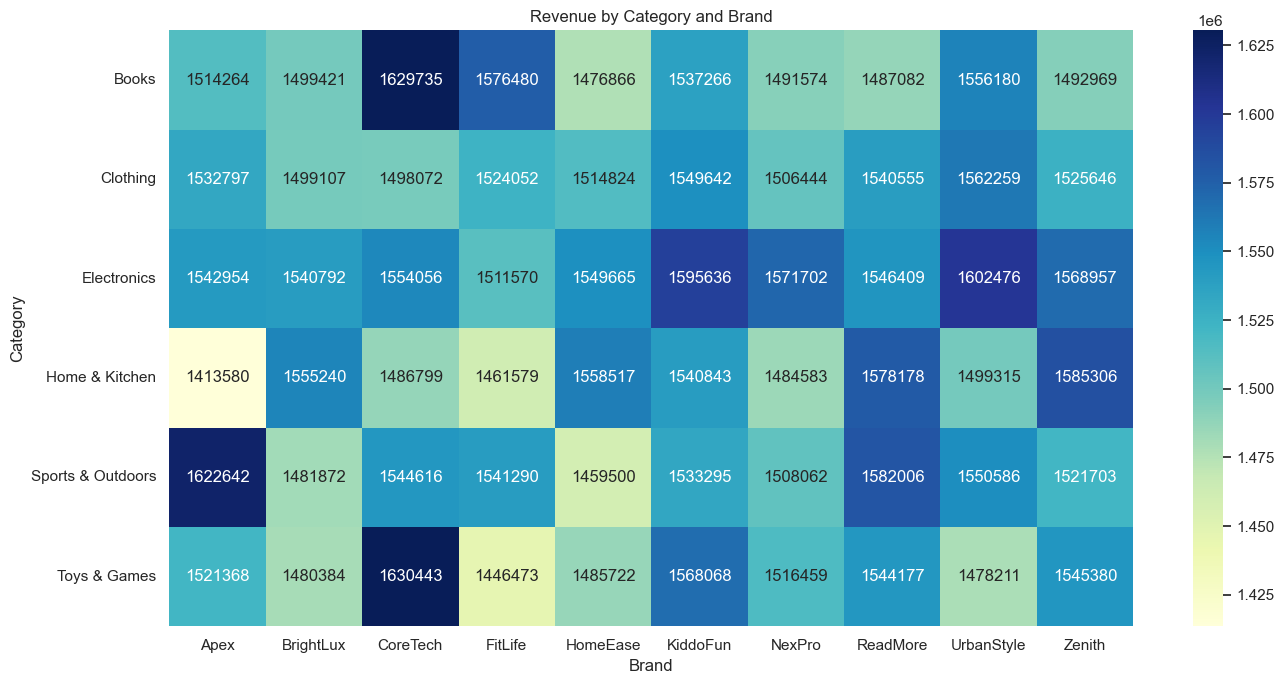

In [44]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    category_brand_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Revenue by Category and Brand")
plt.xlabel("Brand")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 15. Best and Weakest Product Performance

The strongest and weakest products are identified using revenue and unit volume.

A weak product is not automatically considered unsuccessful because the dataset does not provide inventory, product age, marketing spend, or profitability data. The ranking is therefore based strictly on observed sales performance.

In [45]:
best_products = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
)

best_products[
    [
        "ProductName",
        "Category",
        "Brand",
        "Revenue",
        "Units",
        "Orders",
        "Average_Unit_Price",
        "Average_Discount"
    ]
]

,ProductName,Category,Brand,Revenue,Units,Orders,Average_Unit_Price,Average_Discount
1995,Desk Organizer,Clothing,KiddoFun,58059.53,166,58,348.706034,0.095690
1660,Jeans,Sports & Outdoors,Apex,56329.85,156,50,361.225800,0.063000
2794,Memory Card 128GB,Home & Kitchen,HomeEase,55874.05,162,53,341.489623,0.096226
1325,Cookware Set,Books,KiddoFun,53889.96,147,43,379.811860,0.060465
2549,HDMI Cable 2m,Electronics,Zenith,53200.52,154,48,334.984375,0.078125
1120,LED Desk Lamp,Sports & Outdoors,Apex,52494.29,167,52,317.057308,0.082692
467,4K Monitor,Sports & Outdoors,ReadMore,52452.39,181,59,279.351017,0.074576
229,USB-C Charger,Sports & Outdoors,Zenith,52155.04,141,47,358.602340,0.059574
394,Mechanical Keyboard,Home & Kitchen,HomeEase,51373.57,144,43,371.082558,0.070930
1132,LED Desk Lamp,Toys & Games,CoreTech,51046.67,155,43,308.907674,0.074419


In [46]:
weakest_products = (
    product_performance
    .sort_values("Revenue", ascending=True)
    .head(10)
)

weakest_products[
    [
        "ProductName",
        "Category",
        "Brand",
        "Revenue",
        "Units",
        "Orders",
        "Average_Unit_Price",
        "Average_Discount"
    ]
]

,ProductName,Category,Brand,Revenue,Units,Orders,Average_Unit_Price,Average_Discount
961,Electric Kettle,Books,BrightLux,11569.38,44,17,253.458824,0.105882
1230,Backpack,Home & Kitchen,Apex,12113.18,55,17,237.952941,0.070588
1198,Office Chair,Toys & Games,UrbanStyle,13053.29,55,21,249.366667,0.078571
447,4K Monitor,Electronics,ReadMore,13322.53,64,23,261.338696,0.071739
1686,T-Shirt,Books,NexPro,13558.80,60,22,256.466364,0.084091
2245,External HDD 2TB,Electronics,KiddoFun,13642.86,46,19,284.747895,0.084211
2769,Memory Card 128GB,Books,Zenith,13935.50,49,18,309.251111,0.130556
2925,Children's Book,Sports & Outdoors,KiddoFun,14582.76,55,23,275.019130,0.082609
2591,Power Bank 20000mAh,Clothing,BrightLux,14674.16,63,22,257.898182,0.072727
2438,Webcam Full HD,Home & Kitchen,UrbanStyle,14716.87,61,22,243.958182,0.077273


In [47]:
top_category = (
    category_performance
    .sort_values("Revenue", ascending=False)
    .iloc[0]
)

print(
    f"Highest revenue category: "
    f"{top_category['Category']}"
)

print(
    f"Revenue: "
    f"${top_category['Revenue']:,.2f}"
)

print(
    f"Revenue share: "
    f"{top_category['Revenue_Share_%']:.2f}%"
)

Highest revenue category: Electronics
Revenue: $15,584,217.18
Revenue share: 16.97%


In [48]:
top_volume_category = (
    category_volume
    .sort_values("Units_Sold", ascending=False)
    .iloc[0]
)

print(
    f"Highest-volume category: "
    f"{top_volume_category['Category']}"
)

print(
    f"Units sold: "
    f"{top_volume_category['Units_Sold']:,}"
)

Highest-volume category: Electronics
Units sold: 50,696


In [49]:
top_product = product_performance.iloc[0]

print(
    f"Top product by revenue: "
    f"{top_product['ProductName']}"
)

print(
    f"Revenue: "
    f"${top_product['Revenue']:,.2f}"
)

Top product by revenue: Desk Organizer
Revenue: $58,059.53


In [50]:
print(
    f"Top 10 product revenue contribution: "
    f"{top_10_product_revenue_share:.2f}%"
)

Top 10 product revenue contribution: 0.58%


In [51]:
highest_discount_category = (
    category_discount
    .sort_values(
        "Average_Discount",
        ascending=False
    )
    .iloc[0]
)

print(
    f"Highest average discount category: "
    f"{highest_discount_category['Category']}"
)

print(
    f"Average discount: "
    f"{highest_discount_category['Average_Discount']:.2%}"
)

Highest average discount category: Home & Kitchen
Average discount: 7.51%


In [52]:
highest_price_category = (
    category_pricing
    .sort_values(
        "Average_Unit_Price",
        ascending=False
    )
    .iloc[0]
)

print(
    f"Highest average unit-price category: "
    f"{highest_price_category['Category']}"
)

print(
    f"Average unit price: "
    f"${highest_price_category['Average_Unit_Price']:,.2f}"
)

Highest average unit-price category: Clothing
Average unit price: $305.20


In [53]:
product_analysis_summary = pd.DataFrame({
    "Metric": [
        "Total Products",
        "Total Categories",
        "Total Brands",
        "Top Revenue Category",
        "Top Volume Category",
        "Top Revenue Product",
        "Top 10 Product Revenue Share",
        "Highest Discount Category",
        "Highest Average Price Category"
    ],
    "Value": [
        product_count,
        category_count,
        brand_count,
        top_category["Category"],
        top_volume_category["Category"],
        top_product["ProductName"],
        top_10_product_revenue_share,
        highest_discount_category["Category"],
        highest_price_category["Category"]
    ]
})

product_analysis_summary

,Metric,Value
0,Total Products,50
1,Total Categories,6
2,Total Brands,10
3,Top Revenue Category,Electronics
4,Top Volume Category,Electronics
5,Top Revenue Product,Desk Organizer
6,Top 10 Product Revenue Share,0.584669
7,Highest Discount Category,Home & Kitchen
8,Highest Average Price Category,Clothing


In [54]:
output_dir = Path(
    "../Data/Product_Category_Outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory ready.")

Output directory ready.


In [55]:
category_performance.to_csv(
    output_dir / "category_performance.csv",
    index=False
)

category_pricing.to_csv(
    output_dir / "category_pricing.csv",
    index=False
)

category_discount.to_csv(
    output_dir / "category_discount.csv",
    index=False
)

brand_performance.to_csv(
    output_dir / "brand_performance.csv",
    index=False
)

product_performance.to_csv(
    output_dir / "product_performance.csv",
    index=False
)

product_segment_summary.to_csv(
    output_dir / "product_segment_summary.csv"
)

product_concentration.to_csv(
    output_dir / "product_revenue_concentration.csv",
    index=False
)

category_brand_revenue.to_csv(
    output_dir / "category_brand_revenue.csv"
)

product_analysis_summary.to_csv(
    output_dir / "product_analysis_summary.csv",
    index=False
)

print("Product and category analysis tables exported successfully.")

Product and category analysis tables exported successfully.


# 16. Conclusion

This notebook provided a detailed analysis of product and category sales performance.

The analysis examined:

- Category revenue contribution
- Category sales volume
- Category Average Order Value
- Category pricing
- Category discount levels
- Revenue versus sales volume
- Brand performance
- Product revenue rankings
- Product unit-volume rankings
- Product pricing
- Product discounting
- High-value and high-volume product segments
- Product revenue concentration
- Category-brand performance

The analysis identifies products and categories based on observed sales performance rather than profitability because product cost and profit fields are not available in the dataset.

The results provide a foundation for identifying products and categories that should receive further attention in the later business analysis and dashboard stages.